# Feature Engineering & Feature Selection

---

## Pipeline

| Étape | Section | Ce qu'on fait |
|---|---|---|
| Imports | 1 | Charger `config.py` + librairies |
| Chargement | 2 | `df_clean.csv` + `load_features()` |
| Split train/test | 3 | Split 80/20 stratifié — **UNIQUE dans tout le projet** |
| Sélection 1 | 4 | Corrélation avec stroke → supprimer features < 0.05 |
| Sélection 2 | 5 | VIF itératif → supprimer multicolinéarité > 10 |
| Feature Engineering | 6 | Créer 12 features Tier 1 + Tier 2 sur X_train |
| Sélection 3 | 7 | 2ème VIF itératif sur les features engineered |
| Appliquer X_test | 8 | Mêmes transformations appliquées sur X_test |
| Sauvegarde | 9 | `df_train_final.csv` + `df_test_final.csv` + `selected_features.pkl` |

---

**Prérequis** : `2_Preprocessing_v2.ipynb` exécuté → génère `df_clean.csv`  
**Sorties** : `df_train_final.csv`, `df_test_final.csv`, `selected_features.pkl`

## 1. Imports & Configuration

In [1]:
import sys
sys.path.insert(0, './src')
import importlib, config
importlib.reload(config)
from config import (
    TARGET, RANDOM_STATE, CLEAN_PATH,
    check_data_quality, load_features
)

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Chemins de sortie
OUTPUT_DIR        = '../dataset/data_clean/'
TRAIN_OUTPUT      = OUTPUT_DIR + 'df_train_final.csv'
TEST_OUTPUT       = OUTPUT_DIR + 'df_test_final.csv'
FEATURES_PKL      = './'+'selected_features.pkl'

print('Librairies importées avec succès !')
print(f'Input  : {CLEAN_PATH}')
print(f'Output : {TRAIN_OUTPUT}')
print(f'         {TEST_OUTPUT}')
print(f'         {FEATURES_PKL}')

Librairies importées avec succès !
Input  : ../dataset/data_clean/df_clean.csv
Output : ../dataset/data_clean/df_train_final.csv
         ../dataset/data_clean/df_test_final.csv
         ./selected_features.pkl


## 2. Chargement des données

In [2]:
# Chargement du dataset prétraité
df = pd.read_csv(CLEAN_PATH)
df.columns = df.columns.str.strip()
print(f'df_clean.csv chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')

# Chargement des listes de variables depuis features.json
TARGET, CATEGORICAL_VARS, NUMERICAL_VARS, ALL_FEATURES = load_features()

# Vérification qualité
is_clean = check_data_quality(df)
if not is_clean:
    raise ValueError('Dataset non propre — relancer 2_Preprocessing_v2.ipynb.')

df.head(3)

df_clean.csv chargé : 4603 lignes × 36 colonnes
features.json charge :
  target           : stroke
  categorical_vars : 15 variables
  numerical_vars   : 20 variables
  Data Quality Report

Valeurs manquantes : 0
  Aucune valeur manquante.

Doublons : 0
  Aucun doublon.

Shape : 4603 lignes x 36 colonnes


,stroke,gender,age,Race,Marital status,alcohol,smoke,sleep disorder,Health Insurance,General health condition,...,energy,protein,Carbohydrate,Dietary fiber,Total fat,Total saturated fatty acids,Total monounsaturated fatty acids,Total polyunsaturated fatty acids,Potassium,Sodium
0,0,2,2,5,1,0,0,2,2,3,...,1598,62.78,192.19,10.0,65.64,25.112,24.090,8.543,2887.0,2969.0
1,0,2,2,1,1,0,0,1,2,3,...,1547,45.35,256.02,17.0,42.56,13.423,15.389,10.613,2058.0,2091.0
2,1,1,2,3,1,1,1,2,1,3,...,2466,81.56,254.49,13.0,103.32,43.295,36.727,15.366,3117.0,5233.0


## 3. Split Train / Test

Le split est effectué **ici et une seule fois** avant toute sélection ou engineering.  
Toutes les transformations suivantes seront calculées sur `X_train` uniquement,  
puis appliquées à l'identique sur `X_test` — **zéro data leakage**.

In [3]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Split 80/20 stratifié :')
print(f'  X_train : {X_train.shape[0]} lignes × {X_train.shape[1]} colonnes')
print(f'  X_test  : {X_test.shape[0]} lignes × {X_test.shape[1]} colonnes')
print(f'  y_train — stroke=1 : {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'  y_test  — stroke=1 : {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Split 80/20 stratifié :
  X_train : 3682 lignes × 35 colonnes
  X_test  : 921 lignes × 35 colonnes
  y_train — stroke=1 : 290 (7.9%)
  y_test  — stroke=1 : 72 (7.8%)


## 4. Sélection — Étape 1 : Corrélation avec stroke

On calcule la corrélation de Pearson de chaque feature avec `stroke` **sur X_train**.  
Les features avec `|corr| < 0.05` apportent peu d'information prédictive et sont supprimées.

In [4]:
CORR_THRESHOLD = 0.02

# Calculer corrélation sur X_train + y_train 
train_with_target = X_train.copy()
train_with_target[TARGET] = y_train.values

corr_with_target = (
    train_with_target.corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .round(4)
)

# Features à supprimer
low_corr_features = corr_with_target[corr_with_target < CORR_THRESHOLD].index.tolist()
features_after_corr = corr_with_target[corr_with_target >= CORR_THRESHOLD].index.tolist()

print(f'Features supprimées (|corr| < {CORR_THRESHOLD}) : {len(low_corr_features)}')
for f in low_corr_features:
    print(f'   ✗ {f:<40} corr = {corr_with_target[f]:.4f}')

print(f'\nFeatures conservées : {len(features_after_corr)}')
for f in features_after_corr:
    print(f'   ✓ {f:<40} corr = {corr_with_target[f]:.4f}')

Features supprimées (|corr| < 0.02) : 6
   ✗ Glycohemoglobin                          corr = 0.0149
   ✗ Marital status                           corr = 0.0084
   ✗ alcohol                                  corr = 0.0071
   ✗ gender                                   corr = 0.0061
   ✗ High-density lipoprotein                 corr = 0.0057
   ✗ Triglyceride                             corr = 0.0012

Features conservées : 29
   ✓ age                                      corr = 0.1513
   ✓ Coronary Heart Disease                   corr = 0.1431
   ✓ General health condition                 corr = 0.1049
   ✓ protein                                  corr = 0.0811
   ✓ energy                                   corr = 0.0806
   ✓ Diastolic blood pressure                 corr = 0.0793
   ✓ high cholesterol                         corr = 0.0780
   ✓ Total polyunsaturated fatty acids        corr = 0.0737
   ✓ Sodium                                   corr = 0.0736
   ✓ Total fat                    

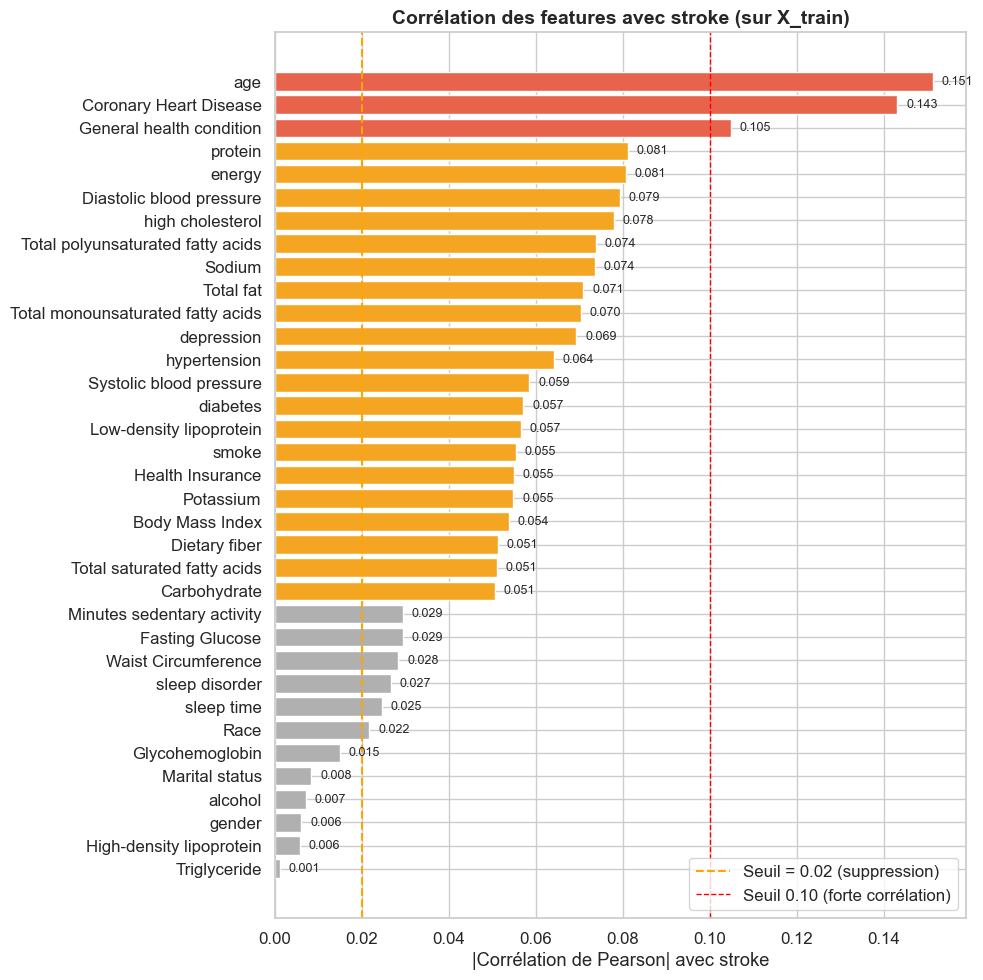

In [5]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 10))

colors = ['#E8634C' if v >= 0.10 else ('#F4A623' if v >= 0.05 else '#B0B0B0')
          for v in corr_with_target.values]

bars = ax.barh(corr_with_target.index, corr_with_target.values,
               color=colors, edgecolor='white')
ax.axvline(x=CORR_THRESHOLD, color='orange', linestyle='--', linewidth=1.5,
           label=f'Seuil = {CORR_THRESHOLD} (suppression)')
ax.axvline(x=0.10, color='red', linestyle='--', linewidth=1,
           label='Seuil 0.10 (forte corrélation)')

for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('|Corrélation de Pearson| avec stroke')
ax.set_title('Corrélation des features avec stroke (sur X_train)', fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Feature Engineering — 12 features médicalement justifiées

On crée 12 nouvelles features sur `X_train[features_after_vif]` uniquement.  
Les mêmes formules seront appliquées à `X_test` à l'étape 8.

> Si une variable source a été supprimée par la sélection, la feature engineered correspondante sera ignorée automatiquement.

In [6]:
def add_engineered_features(X_df, selected_features):
    """
    Crée les features engineered sur X_df.
    Vérifie la présence des variables sources avant chaque création.
    Retourne X_df enrichi + liste des features créées.
    """
    X = X_df.copy()
    created = []

    def has(*cols):
        return all(c in X.columns for c in cols)

    # ── TIER 1 ── Score de risque cardiovasculaire

    # cardio_risk_score — sans CHD pour éviter VIF infini
    tier1_cols    = ['hypertension', 'diabetes', 'high cholesterol', 'smoke']
    available_t1  = [c for c in tier1_cols if c in X.columns]
    if len(available_t1) >= 2:
        X['cardio_risk_score'] = X[available_t1].sum(axis=1)
        created.append('cardio_risk_score')
        print(f'  ✓ cardio_risk_score  (somme de {len(available_t1)} facteurs)')

    # age × CHD — interaction spécifique maladie coronarienne
    if has('age', 'Coronary Heart Disease'):
        X['age_CHD'] = X['age'] * X['Coronary Heart Disease']
        created.append('age_CHD')
        print(f'  ✓ age_CHD')

    # ── TIER 2 ── Interactions biologiques

    # Pression pulsée — marqueur rigidité artérielle
    if has('Systolic blood pressure', 'Diastolic blood pressure'):
        X['pulse_pressure'] = X['Systolic blood pressure'] - X['Diastolic blood pressure']
        created.append('pulse_pressure')
        print(f'  ✓ pulse_pressure')

    # HbA1c × diabète — double marqueur glycémique
    if has('Glycohemoglobin', 'diabetes'):
        X['hba1c_diabetes'] = X['Glycohemoglobin'] * X['diabetes']
        created.append('hba1c_diabetes')
        print(f'  ✓ hba1c_diabetes')

    # Ratio LDL/HDL — profil lipidique cardiovasculaire
    if has('Low-density lipoprotein', 'High-density lipoprotein'):
        X['ldl_hdl_ratio'] = X['Low-density lipoprotein'] / (X['High-density lipoprotein'] + 1e-6)
        created.append('ldl_hdl_ratio')
        print(f'  ✓ ldl_hdl_ratio')

    # ── TIER 2 ── Santé mentale × accès aux soins

    # Dépression × assurance — profil vulnérable sans accès aux soins
    if has('depression', 'Health Insurance'):
        X['depression_insurance'] = X['depression'] * X['Health Insurance']
        created.append('depression_insurance')
        print(f'  ✓ depression_insurance')


    # ── TIER 2 ── Alimentation

    # Ratio graisses saturées / polyinsaturées — alimentation pro-inflammatoire
    if has('Total saturated fatty acids', 'Total polyunsaturated fatty acids'):
        X['fat_ratio'] = X['Total saturated fatty acids'] / (X['Total polyunsaturated fatty acids'] + 1e-6)
        created.append('fat_ratio')
        print(f'  ✓ fat_ratio')

    # Fibres × cholestérol élevé — effet protecteur des fibres
    if has('Dietary fiber', 'high cholesterol'):
        X['fiber_cholesterol'] = X['Dietary fiber'] * X['high cholesterol']
        created.append('fiber_cholesterol')
        print(f'  ✓ fiber_cholesterol')

    # ── TIER 3 ── Tabac × comorbidités

    # Fumeur hypertendu — risque AVC multiplié
    if has('smoke', 'hypertension'):
        X['smoke_hypertension'] = X['smoke'] * X['hypertension']
        created.append('smoke_hypertension')
        print(f'  ✓ smoke_hypertension')

    # Fumeur diabétique
    if has('smoke', 'diabetes'):
        X['smoke_diabetes'] = X['smoke'] * X['diabetes']
        created.append('smoke_diabetes')
        print(f'  ✓ smoke_diabetes')

    return X, created


print('=== Feature Engineering sur X_train ===')
X_train_eng, ENGINEERED_FEATURES = add_engineered_features(
    X_train[features_after_corr], features_after_corr
)

FINAL_FEATURES = X_train_eng.columns.tolist()

print(f'\nFeatures originales (apres correlation) : {len(features_after_corr)}')
print(f'Nouvelles features creees               : {len(ENGINEERED_FEATURES)}')
print(f'Total features finales                  : {len(FINAL_FEATURES)}')


=== Feature Engineering sur X_train ===
  ✓ cardio_risk_score  (somme de 4 facteurs)
  ✓ age_CHD
  ✓ pulse_pressure
  ✓ depression_insurance
  ✓ fat_ratio
  ✓ fiber_cholesterol
  ✓ smoke_hypertension
  ✓ smoke_diabetes

Features originales (apres correlation) : 29
Nouvelles features creees               : 8
Total features finales                  : 37


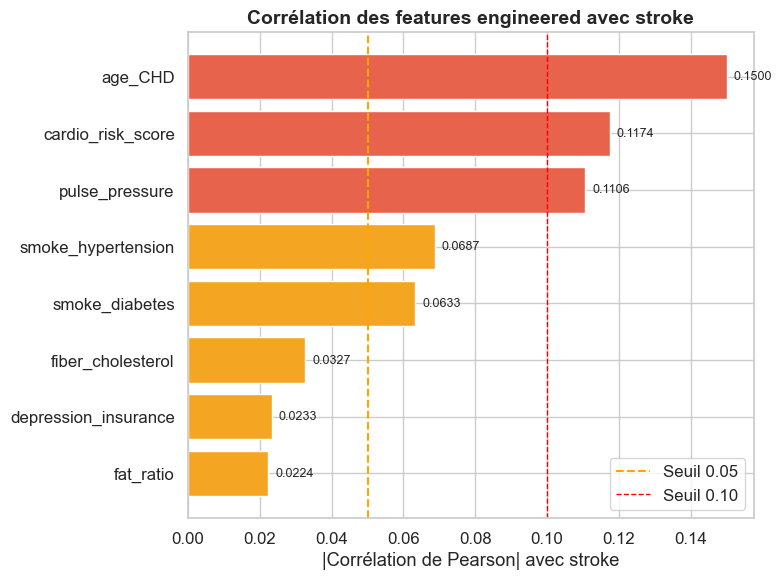


Corrélations features engineered :
age_CHD                 0.1500
cardio_risk_score       0.1174
pulse_pressure          0.1106
smoke_hypertension      0.0687
smoke_diabetes          0.0633
fiber_cholesterol       0.0327
depression_insurance    0.0233
fat_ratio               0.0224
Name: stroke, dtype: float64


In [7]:
# Corrélation des nouvelles features avec stroke
eng_with_target = X_train_eng[ENGINEERED_FEATURES].copy()
eng_with_target[TARGET] = y_train.values

corr_eng = (
    eng_with_target.corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .round(4)
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E8634C' if v >= 0.10 else '#F4A623' for v in corr_eng.values]
ax.barh(corr_eng.index, corr_eng.values, color=colors, edgecolor='white')
ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=1.5, label='Seuil 0.05')
ax.axvline(x=0.10, color='red', linestyle='--', linewidth=1, label='Seuil 0.10')
for i, val in enumerate(corr_eng.values):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('|Corrélation de Pearson| avec stroke')
ax.set_title('Corrélation des features engineered avec stroke', fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nCorrélations features engineered :')
print(corr_eng)

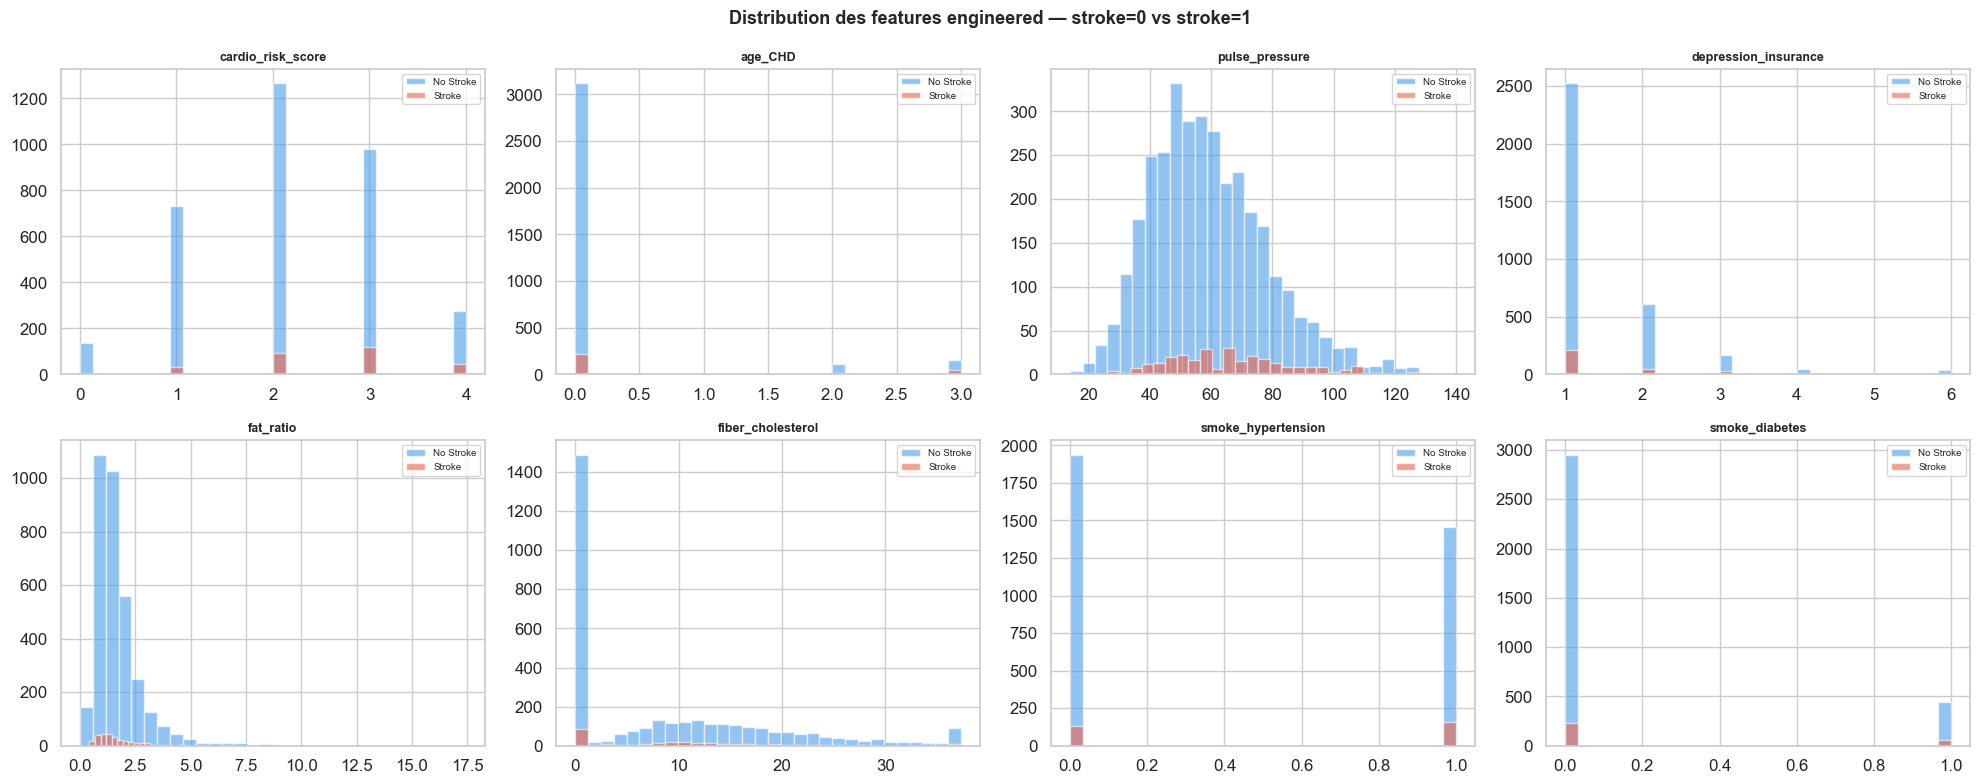

In [8]:
# Distribution des features engineered — stroke=0 vs stroke=1
n_cols_plot = 4
n_rows_plot = (len(ENGINEERED_FEATURES) + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(20, 4 * n_rows_plot))
axes = axes.flatten()

for i, feat in enumerate(ENGINEERED_FEATURES):
    for cls, color, label in [(0, '#4C9BE8', 'No Stroke'), (1, '#E8634C', 'Stroke')]:
        mask = y_train.values == cls
        axes[i].hist(X_train_eng[feat][mask], bins=30,
                     alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(len(ENGINEERED_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des features engineered — stroke=0 vs stroke=1',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Appliquer les transformations sur X_test

On applique exactement les mêmes transformations sur `X_test` :  
- Restreindre aux `features_after_vif` (sélection 1 + 2)  
- Créer les mêmes features engineered
- Restreindre aux `FINAL_FEATURES` (sélection 3)  

In [9]:
print('=== Application des transformations sur X_test ===')
X_test_eng, _ = add_engineered_features(
    X_test[features_after_corr], features_after_corr
)

# Restreindre aux features finales
X_train_final = X_train_eng[FINAL_FEATURES].copy()
X_test_final  = X_test_eng[FINAL_FEATURES].copy()

print(f'\nX_train_final : {X_train_final.shape[0]} lignes × {X_train_final.shape[1]} colonnes')
print(f'X_test_final  : {X_test_final.shape[0]} lignes × {X_test_final.shape[1]} colonnes')

# Vérifications
assert X_train_final.isnull().sum().sum() == 0, 'NaN dans X_train_final !'
assert X_test_final.isnull().sum().sum()  == 0, 'NaN dans X_test_final !'
assert list(X_train_final.columns) == list(X_test_final.columns), 'Colonnes différentes !'
print('\n✓ Vérifications OK — aucun NaN, colonnes identiques')

=== Application des transformations sur X_test ===
  ✓ cardio_risk_score  (somme de 4 facteurs)
  ✓ age_CHD
  ✓ pulse_pressure
  ✓ depression_insurance
  ✓ fat_ratio
  ✓ fiber_cholesterol
  ✓ smoke_hypertension
  ✓ smoke_diabetes

X_train_final : 3682 lignes × 37 colonnes
X_test_final  : 921 lignes × 37 colonnes

✓ Vérifications OK — aucun NaN, colonnes identiques


## 9. Sauvegarde

On sauvegarde :
- `df_train_final.csv` — X_train + y_train (features finales)
- `df_test_final.csv`  — X_test + y_test (features finales)
- `selected_features.pkl` — liste des features finales (chargée par Modeling)

In [10]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_train_final = X_train_final.copy()
df_train_final[TARGET] = y_train.values

df_test_final = X_test_final.copy()
df_test_final[TARGET] = y_test.values

df_train_final.to_csv(TRAIN_OUTPUT, index=False)
df_test_final.to_csv(TEST_OUTPUT,  index=False)

with open(FEATURES_PKL, 'wb') as f:
    pickle.dump(FINAL_FEATURES, f)

print('=== Sauvegarde terminee ===')
print(f'  df_train_final.csv : {df_train_final.shape[0]} lignes x {df_train_final.shape[1]} colonnes')
print(f'  df_test_final.csv  : {df_test_final.shape[0]} lignes x {df_test_final.shape[1]} colonnes')
print(f'  selected_features.pkl : {len(FINAL_FEATURES)} features')

df_train_check = pd.read_csv(TRAIN_OUTPUT)
df_test_check  = pd.read_csv(TEST_OUTPUT)
print(f'\n✓ Verification relecture :')
print(f'  Train : {df_train_check.shape} — NaN : {df_train_check.isnull().sum().sum()}')
print(f'  Test  : {df_test_check.shape}  — NaN : {df_test_check.isnull().sum().sum()}')

print(f'\n=== Resume pipeline Feature Engineering ===')
print(f'  Features originales      : {len(ALL_FEATURES)}')
print(f'  Apres filtre correlation : {len(features_after_corr)}')
print(f'  + Features engineered    : {len(ENGINEERED_FEATURES)}')
print(f'  Features finales totales : {len(FINAL_FEATURES)}')
print(f'\nFeature Engineering termine.')


=== Sauvegarde terminee ===
  df_train_final.csv : 3682 lignes x 38 colonnes
  df_test_final.csv  : 921 lignes x 38 colonnes
  selected_features.pkl : 37 features

✓ Verification relecture :
  Train : (3682, 38) — NaN : 0
  Test  : (921, 38)  — NaN : 0

=== Resume pipeline Feature Engineering ===
  Features originales      : 35
  Apres filtre correlation : 29
  + Features engineered    : 8
  Features finales totales : 37

Feature Engineering termine.
